# Carry Trade Risk Analysis

A carry trade borrows in a low-rate currency and invests in a high-rate currency,
pocketing the interest rate differential.

**Regulatory context:**
- FRTB SA -- FX delta risk, GIRR delta risk
- EMIR -- FX forwards and swaps used to implement carry are reportable OTC derivatives
- AIFMD II -- leverage and risk monitoring for funds running carry strategies

**Contents:**
1. Carry trade mechanics
2. EUR/USD carry -- current rate environment
3. P&L decomposition -- carry vs spot move
4. Carry-to-risk ratio
5. When carry breaks -- unwind scenarios
6. Multi-currency carry portfolio
7. FRTB risk classification

**Notation**

$$\text{F}_\text{X} = \text{BASE} / \text{QUOTE}$$

Buy / sell the $\text{BASE}$ in $x$ units of $\text{QUOTE}$

And using this notation, thisis the CIP: 

$$F_0 = S_0 \, e^{(r_{QUOTE} - r_{BASE}) T}$$


In [1]:
from quant_risk.setup import base, asset_pricing

np, pd, plt = base()
ois_curve, nss_curve, valuation_date, calendar, ql = asset_pricing()

C1, C2, C3, C4 = '#2E75B6', '#ED7D31', '#A9D18E', '#C00000'
day_count = ql.Actual365Fixed()

base loaded
OISCurve | currency=EUR | valuation_date=2026-03-24
NSSCurve | currency=EUR | valuation_date=2026-05-04
Valuation date : March 24th, 2026
Calendar       : TARGET
asset pricing loaded


## 1. Carry Trade

Relevant terms:
* covered interest rate parity (CIP)
* uncovered interest rate parity (UIP)


The carry trade exploits the interest rate differential between two currencies.
Under CIP, this differential is fully embedded in the forward rate. In practice, CIP holds for short-term liquid instruments but
the UIP, which says spot moves will offset
the differential, fails empirically, giving space for a carry trade. The carry is certain (known at trade date). The spot return is uncertain.


**P&L components (per unit of low-rate currency borrowed):**

$$P\&L^{HIGH} = \underbrace{(r_{HIGH} - r_{LOW}) \cdot T}_{\text{carry}} + \underbrace{\frac{S_T^{HIGH/LOW} - S_0^{HIGH/LOW}}{S_0^{HIGH/LOW}}}_{\text{spot return}}$$

where $S^{HIGH/LOW}$ is quoted as units of low-rate currency per one unit of high-rate currency.

Ex: USD/JPY, where S0 = 160, base USD, quote yen, 160Yen = 1USD


$$P\&L^{USD} = \underbrace{(r_{USD} - r_{JPY}) \cdot T}_{\text{carry}} + \underbrace{\frac{S_T^{USD/JPY} - S_0^{USD/JPY}}{S_0^{USD/JPY}}}_{\text{spot return}}$$

- P&L is in USD (high rate currency, base currency)
- Carry is $(r_{USD} - r_{JPY}) > 0$
- Spot return is positive when JPY weakens ($S_T^{USD/JPY} > S_0^{USD/JPY}$)


Important: carry traders are highly leveraged and regime changes produce
extreme events. A spike in $r_{JPY}$ triggers margin calls on derivative
structures used to fund the trade. Funds are forced to sell foreign assets
and buy back JPY in spot, driving $S_T^{USD/JPY}$ down (JPY appreciates).
This makes the spot return term $\frac{S_T^{USD/JPY} - S_0^{USD/JPY}}{S_0^{USD/JPY}}$
sharply negative, while the carry term $(r_{USD} - r_{JPY})$ is compressed. 

---

### 1.1. CIP: The No-Arbitrage Benchmark

Quote convention: $S_0^{BASE/QUOTE}$, units of QUOTE per 1 BASE. No-arbitrage pins the forward rate:

$$F_0 = S_0 \, e^{(r_{QUOTE} - r_{BASE}) T}$$

* If $r_{QUOTE} < r_{BASE}$: $F_0 < S_0^{BASE/QUOTE}$, QUOTE appreciates in forward terms.
* If $r_{QUOTE} > r_{BASE}$: $F_0 > S_0^{BASE/QUOTE}$, QUOTE depreciates in forward terms.

Any fully hedged (covered) position yields exactly:

$$P\&L^{BASE} = S_0 \, e^{(r_{QUOTE} - r_{BASE}) T} - F_0 = 0$$


### 1.2. UIP and the Carry Trade Thesis

UIP states that the expected future spot equals the CIP forward (USD/JPY convention):

$$E[S_T^{USD/JPY}] = F_0 = S_0^{USD/JPY} \, e^{(r_{JPY} - r_{USD}) T}$$

Since $r_{JPY} < r_{USD}$: $F_0 < S_0^{USD/JPY}$, meaning UIP predicts JPY appreciation
large enough to fully offset the carry, leaving zero expected profit from going unhedged.

**UIP fails empirically.** JPY appreciates less than implied by $F_0$ on average,
so the spot return term does not fully cancel the carry term. This is the carry trade opportunity.

The carry trade is a bet on FX stability: $S_T^{USD/JPY} \approx S_0^{USD/JPY}$.

The spot return term is expected to be near zero. The profit engine is the
carry term $(r_{USD} - r_{JPY}) \cdot T$, which is small but becomes large
when leveraged. A fund running 10x leverage on a 3% differential earns
30% on equity per year if spot does not move.

The risk is that $S_T^{USD/JPY}$ moves sharply against the position.
Because of leverage, a 10% appreciation of JPY ($S_T^{USD/JPY}$ falls 10%)
wipes out more than three years of carry income in a single move.

This is the classic carry trade profile: small steady gains, rare catastrophic losses.

---

### 1.3. Uncovered Carry Trade: USD/JPY Mechanics

<small> 

| Step | Action | $t=0$ (USD) | $t=T$ (USD) |
|------|--------|-------------|-------------|
| 1 | Borrow $K$ JPY at $r_{JPY}$ | $+\frac{K}{S_0^{USD/JPY}}$ | $-\frac{K \, e^{r_{JPY}T}}{S_T^{USD/JPY}}$ |
| 2 | Invest USD at $r_{USD}$ | $-\frac{K}{S_0^{USD/JPY}}$ | $+\frac{K}{S_0^{USD/JPY}} e^{r_{USD}T}$ |
| **Net** | | **0** | $\frac{K}{S_0^{USD/JPY}}\left(e^{r_{USD}T} - \frac{S_0^{USD/JPY} \, e^{r_{JPY}T}}{S_T^{USD/JPY}}\right)$ |

</small> 

The FX leg at maturity is unhedged. Exact P&L in USD:

$$P\&L^{USD} = \frac{K}{S_0^{USD/JPY}} e^{r_{USD}T} - \frac{K \, e^{r_{JPY}T}}{S_T^{USD/JPY}}$$

Approximate decomposition (first order):

$$P\&L^{USD} \approx \underbrace{(r_{USD} - r_{JPY}) \cdot T}_{\text{carry}} + \underbrace{\frac{S_T^{USD/JPY} - S_0^{USD/JPY}}{S_0^{USD/JPY}}}_{\text{spot return}}$$

In [2]:
# ── current rate environment -- March 24 2026 ────────────────────────────────
# EUR OIS from bootstrapped curve
eur_1y = ois_curve.zero_rate(1.0) / 100
eur_3m = ois_curve.zero_rate(0.25) / 100

# USD rates -- from FRED (aligned to valuation date)
usd_1y = 0.0381   # USD Treasury 1Y
usd_3m = 0.0374   # USD Treasury 3M

spot_eurusd = 1.1578   # EUR/USD spot

# rate differentials
diff_1y = usd_1y - eur_1y
diff_3m = usd_3m - eur_3m

print(f"Rate environment -- March 24 2026")
print(f"{'':20} {'EUR OIS':>10} {'USD':>10} {'Differential':>14}")
print("-" * 58)
print(f"{'3M':20} {eur_3m*100:>10.3f}% {usd_3m*100:>10.3f}% {diff_3m*100:>12.3f}%")
print(f"{'1Y':20} {eur_1y*100:>10.3f}% {usd_1y*100:>10.3f}% {diff_1y*100:>12.3f}%")
print(f"\nSpot EUR/USD: {spot_eurusd:.4f}")
print(f"\nCarry trade direction: borrow EUR, invest USD")
print(f"Annual carry (1Y): {diff_1y*100:.2f}% = {diff_1y*100:.0f}bps")

Rate environment -- March 24 2026
                        EUR OIS        USD   Differential
----------------------------------------------------------
3M                        1.979%      3.740%        1.761%
1Y                        2.003%      3.810%        1.807%

Spot EUR/USD: 1.1578

Carry trade direction: borrow EUR, invest USD
Annual carry (1Y): 1.81% = 2bps


## 2. EUR-funded carry trade

We implement the carry trade via an FX forward -- buy EUR forward (deliver USD,
receive EUR) at the CIP forward rate. This is equivalent to:
- Borrowing EUR at $r_{EUR}$
- Converting to USD at spot
- Investing USD at $r_{USD}$
- Locking in the forward conversion rate

The carry is the forward premium -- the difference between the forward rate and spot.

In [3]:
# ── CIP forward rates ────────────────────────────────────────────────────────
tenors_carry = {'1M': 1/12, '3M': 0.25, '6M': 0.5, '1Y': 1.0, '2Y': 2.0}

# USD ZeroCurve
day_count_fx = ql.Actual360()
us_cal       = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
usd_dates    = [valuation_date] + [
    valuation_date + ql.Period(max(1, int(t*365)), ql.Days)
    for t in [0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
]
usd_rates_input = [0.0363, 0.0374, 0.0378, 0.0381, 0.0390, 0.0403, 0.0439]
usd_zc = ql.ZeroCurve(usd_dates, usd_rates_input, day_count_fx, us_cal, ql.Linear(), ql.Continuous)
usd_zc.enableExtrapolation()

# EUR ZeroCurve
eur_tenors_list = [0.0, 1/12, 3/12, 6/12, 1.0, 2.0, 5.0]
eur_dates_list  = [
    valuation_date if t == 0
    else valuation_date + ql.Period(max(1, int(t*365)), ql.Days)
    for t in eur_tenors_list
]
eur_rates_list = [ois_curve.zero_rate(max(t, 1/365)) / 100 for t in eur_tenors_list]
eur_zc = ql.ZeroCurve(eur_dates_list, eur_rates_list, day_count_fx, ql.TARGET(), ql.Linear(), ql.Continuous)
eur_zc.enableExtrapolation()

print(f"{'Tenor':<8} {'EUR rate':>10} {'USD rate':>10} {'Forward':>10} {'Fwd pts':>10} {'Carry':>10}")
print("-" * 62)
carry_data = {}
for label, T in tenors_carry.items():
    dt     = valuation_date + ql.Period(max(1, int(T*365)), ql.Days)
    df_eur = eur_zc.discount(dt)
    df_usd = usd_zc.discount(dt)
    fwd    = spot_eurusd * df_eur / df_usd
    fwd_pts = (fwd - spot_eurusd) * 10000   # in pips
    carry_pct = (fwd - spot_eurusd) / spot_eurusd * 100
    carry_data[label] = {'T': T, 'fwd': fwd, 'fwd_pts': fwd_pts, 'carry_pct': carry_pct}
    eur_r = -np.log(df_eur) / T
    usd_r = -np.log(df_usd) / T
    print(f"{label:<8} {eur_r*100:>10.3f}% {usd_r*100:>10.3f}% {fwd:>10.4f} {fwd_pts:>8.1f}pp {carry_pct:>8.2f}%")

Tenor      EUR rate   USD rate    Forward    Fwd pts      Carry
--------------------------------------------------------------
1M            1.937%      3.666%     1.1595     16.7pp     0.14%
3M            2.001%      3.782%     1.1630     51.7pp     0.45%
6M            2.075%      3.822%     1.1680    101.6pp     0.88%
1Y            2.030%      3.863%     1.1792    214.1pp     1.85%
2Y            2.161%      3.954%     1.2001    422.8pp     3.65%


## 3. P&L Decomposition -- Carry vs Spot Move

The total return on a carry trade decomposes into:

$$P\&L_{total} = \underbrace{carry}_{certain} + \underbrace{spot\ return}_{uncertain}$$

We simulate the range of outcomes for the 1Y EUR/USD carry trade across
different spot scenarios at maturity.

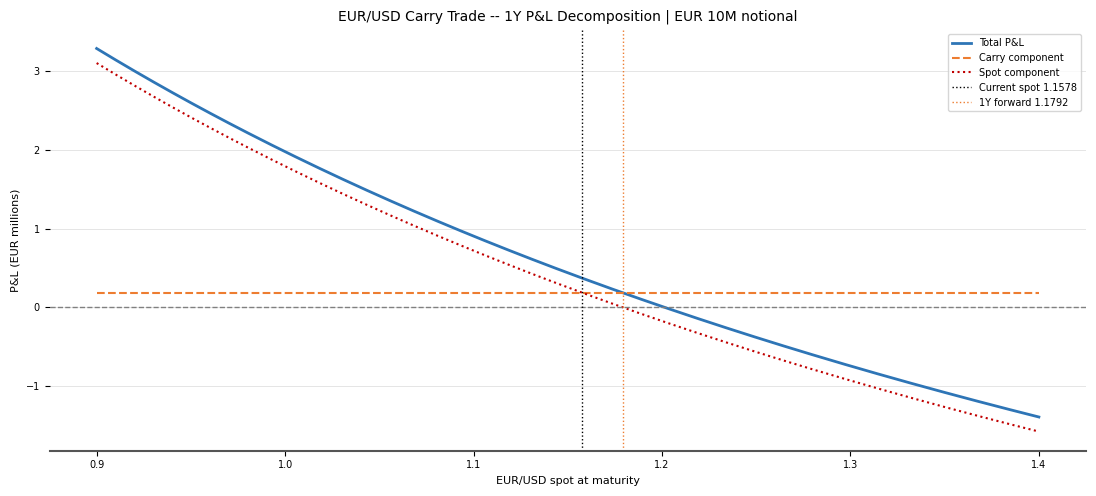

Trade: borrow EUR 10M, invest USD, lock in forward at 1.1792
Annual carry:     EUR 184,936 (1.85% of notional)
Break-even spot:  1.1792 (forward rate -- carry offsets exactly)
Trade profits if EUR/USD at maturity < 1.1792


In [4]:
# ── 1Y carry trade P&L decomposition ─────────────────────────────────────────
notional_eur = 10_000_000   # EUR 10M borrowed
T            = 1.0

dt_1y  = valuation_date + ql.Period(365, ql.Days)
df_eur = eur_zc.discount(dt_1y)
df_usd = usd_zc.discount(dt_1y)
fwd_1y = spot_eurusd * df_eur / df_usd

# carry in EUR terms -- forward premium received
carry_eur = notional_eur * (fwd_1y - spot_eurusd) / spot_eurusd

# spot scenarios at maturity -- EUR/USD range
spot_T = np.linspace(0.90, 1.40, 200)

# P&L: carry trade = sell EUR forward at fwd_1y, buy back at spot_T
# gain when EUR depreciates (spot_T < fwd_1y)
pnl_carry    = np.full_like(spot_T, carry_eur / 1e6)   # constant carry in EUR m
pnl_spot     = notional_eur * (fwd_1y - spot_T) / spot_T / 1e6   # spot return
pnl_total    = pnl_carry + pnl_spot

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(spot_T, pnl_total, color=C1, linewidth=2, label='Total P&L')
ax.plot(spot_T, pnl_carry, color=C2, linewidth=1.5, linestyle='--', label='Carry component')
ax.plot(spot_T, pnl_spot,  color=C4, linewidth=1.5, linestyle=':',  label='Spot component')
ax.axhline(0, color='grey', linewidth=1, linestyle='--')
ax.axvline(spot_eurusd, color='black', linewidth=1, linestyle=':', label=f'Current spot {spot_eurusd}')
ax.axvline(fwd_1y, color=C2, linewidth=1, linestyle=':', label=f'1Y forward {fwd_1y:.4f}')
ax.set_xlabel('EUR/USD spot at maturity')
ax.set_ylabel('P&L (EUR millions)')
ax.set_title('EUR/USD Carry Trade -- 1Y P&L Decomposition | EUR 10M notional')
ax.legend()
ax.spines['bottom'].set_color('#555555')
plt.tight_layout()
plt.show()

print(f"Trade: borrow EUR {notional_eur/1e6:.0f}M, invest USD, lock in forward at {fwd_1y:.4f}")
print(f"Annual carry:     EUR {carry_eur:,.0f} ({carry_eur/notional_eur*100:.2f}% of notional)")
print(f"Break-even spot:  {fwd_1y:.4f} (forward rate -- carry offsets exactly)")
print(f"Trade profits if EUR/USD at maturity < {fwd_1y:.4f}")

## 4. Carry-to-Risk Ratio

The carry-to-risk ratio is the key metric for evaluating carry trades:

$$Carry\text{-}to\text{-}Risk = \frac{\text{Annual carry}}{\text{Implied volatility}}$$

It measures how much carry you earn per unit of FX volatility risk.
A ratio above 0.5 is generally considered attractive.

**Break-even volatility:** the annualised vol at which the expected spot
move would wipe out the carry. If implied vol > break-even vol,
the carry is not compensating for the risk.

Carry-to-Risk Analysis -- EUR/USD 1Y
Annual carry:          1.85%
1Y ATM implied vol:    8.20%
Carry-to-risk ratio:   0.23x
Break-even vol:        1.85%

Interpretation:
  Carry-to-risk 0.23x < 0.5 -- carry is thin relative to implied vol


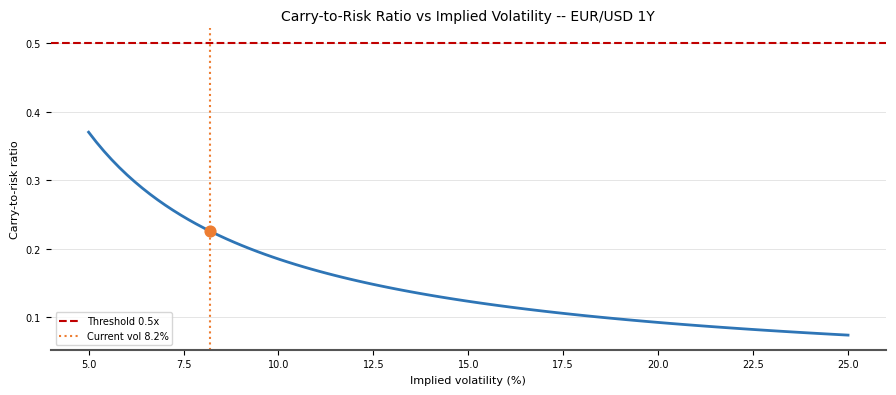

In [5]:
# ── carry-to-risk ratio ───────────────────────────────────────────────────────
# EUR/USD 1Y ATM implied vol -- approximate current level
impl_vol_1y = 0.0820   # 8.20% -- typical EUR/USD 1Y vol

# annual carry as % of spot
annual_carry_pct = (fwd_1y - spot_eurusd) / spot_eurusd * 100

# carry to risk ratio
carry_to_risk = annual_carry_pct / (impl_vol_1y * 100)

# break-even vol -- vol level where 1 sigma move wipes out carry
breakeven_vol = annual_carry_pct / 100   # carry as fraction

print(f"Carry-to-Risk Analysis -- EUR/USD 1Y")
print(f"Annual carry:          {annual_carry_pct:.2f}%")
print(f"1Y ATM implied vol:    {impl_vol_1y*100:.2f}%")
print(f"Carry-to-risk ratio:   {carry_to_risk:.2f}x")
print(f"Break-even vol:        {breakeven_vol*100:.2f}%")
print(f"\nInterpretation:")
if carry_to_risk > 0.5:
    print(f"  Carry-to-risk {carry_to_risk:.2f}x > 0.5 -- carry is attractive relative to risk")
else:
    print(f"  Carry-to-risk {carry_to_risk:.2f}x < 0.5 -- carry is thin relative to implied vol")

# ── carry to risk across vol scenarios ───────────────────────────────────────
vols = np.linspace(0.05, 0.25, 100)
ctrs = annual_carry_pct / (vols * 100)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(vols * 100, ctrs, color=C1, linewidth=2)
ax.axhline(0.5, color=C4, linestyle='--', linewidth=1.5, label='Threshold 0.5x')
ax.axvline(impl_vol_1y * 100, color=C2, linestyle=':', linewidth=1.5,
           label=f'Current vol {impl_vol_1y*100:.1f}%')
ax.scatter([impl_vol_1y * 100], [carry_to_risk], color=C2, zorder=5, s=60)
ax.set_xlabel('Implied volatility (%)')
ax.set_ylabel('Carry-to-risk ratio')
ax.set_title('Carry-to-Risk Ratio vs Implied Volatility -- EUR/USD 1Y')
ax.legend()
ax.spines['bottom'].set_color('#555555')
plt.tight_layout()
plt.show()

## 5. When Carry Breaks -- Unwind Scenarios

Carry trades are described as "picking up nickels in front of a steamroller" --
steady small gains punctuated by sudden large losses. The unwind is typically
triggered by a risk-off event:

- Central bank surprise (rate cut in high-rate currency)
- Global risk-off (flight to safe havens -- JPY, CHF, USD)
- Volatility spike (VIX > 25 historically associated with carry unwinds)
- Margin calls forcing position liquidation

The unwind is self-reinforcing -- forced sellers push the high-rate currency
lower, triggering more stops and margin calls.


### The 2024 JPY-funded carry trade unwind: Mechanics

#### The actual position structure
<small> 

| Leg | Instrument | Variable |
|-----|-----------|----------|
| Funding (short JPY) | JPY loans, FX forwards, FX swaps, JGB futures shorts | $r_{JPY}$ |
| Investment (long USD) | US Treasuries, US equities, EM bonds | $r_{USD}$, asset prices |

</small> 

Because the carry $(r_{USD} - r_{JPY})$ is thin, positions were run with
heavy leverage via prime brokers. A fund with \$100m equity might hold
\$500m-\$1bn of gross exposure. This is the critical structural feature.


##### **Step 1: BoJ hikes $r_{JPY}$ by 15bps (July 2024)**

$$r_{JPY} \uparrow \implies (r_{USD} - r_{JPY}) \downarrow$$

Carry income compressed. Trade becomes less attractive on a forward-looking basis.


##### **Step 2: Volatility spikes**

$$\sigma^{USD/JPY} \uparrow$$

Prime brokers reprice margin requirements on all JPY short positions.
Margin on JGB futures shorts increased 43%. Margin calls go out.



##### **Step 3: Forced liquidation of the asset side**

To meet margin calls, funds must raise cash:

$$\text{sell: US Treasuries, US equities, EM bonds} \implies \text{asset prices} \downarrow$$

This is why the Nikkei dropped 12.4% and S&P 500 fell 3% on August 5.
The equity crash had no fundamental cause. It was pure forced deleveraging.



##### **Step 4: JPY short positions must be closed**

$$\text{buy JPY in spot} \implies S_T^{USD/JPY} \downarrow$$

JPY appreciates. Fewer JPY per USD. This is the counterintuitive part:

$$r_{JPY} \uparrow \xrightarrow{\text{CIP}} S_T^{USD/JPY} \uparrow \text{ (JPY should weaken)}$$

$$r_{JPY} \uparrow \xrightarrow{\text{unwind}} S_T^{USD/JPY} \downarrow \text{ (JPY actually strengthened)}$$

The unwind effect completely dominated the CIP mechanical effect.



##### **Step 5: Feedback loop**

$$S_T^{USD/JPY} \downarrow \implies \text{P\&L on remaining positions} \downarrow \implies \text{more margin calls} \implies S_T^{USD/JPY} \downarrow \text{ further}$$

Self-reinforcing until positions are exhausted or a circuit breaker appears.
The circuit breaker in August 2024 was the BoJ publicly stating it would
pause further hikes. That broke the feedback loop within days.

---

#### Summary: the counterintuitive chain

$$r_{JPY} \uparrow
\implies \text{margin calls on derivatives}
\implies \text{forced asset sales}
\implies \text{JPY bought back in spot}
\implies S_T^{USD/JPY} \downarrow \text{ (JPY strengthens)}
\implies \text{spot return term} \frac{S_T^{USD/JPY} - S_0^{USD/JPY}}{S_0^{USD/JPY}} < 0$$

The rate hike hurt not through the carry term directly,
but by triggering margin calls on leveraged derivative structures
that forced spot JPY buying, which then destroyed the spot return term.

In [6]:
# ── carry unwind scenarios ────────────────────────────────────────────────────
scenarios = {
    'Base (UIP holds)':        fwd_1y,          # spot moves to forward -- zero carry P&L
    'Carry works (EUR -5%)':   spot_eurusd * 0.95,  # EUR depreciates -- carry trade wins
    'Mild unwind (EUR +3%)':   spot_eurusd * 1.03,
    'Severe unwind (EUR +8%)': spot_eurusd * 1.08,
    'Crisis unwind (EUR +15%': spot_eurusd * 1.15,
}

print(f"{'Scenario':<30} {'Spot at T':>10} {'Carry P&L':>12} {'Spot P&L':>12} {'Total P&L':>12}")
print("-" * 80)
for label, spot_T_val in scenarios.items():
    carry_pnl = carry_eur
    spot_pnl  = notional_eur * (fwd_1y - spot_T_val) / spot_T_val
    total_pnl = carry_pnl + spot_pnl
    print(f"{label:<30} {spot_T_val:>10.4f} {carry_pnl/1e3:>10.1f}k {spot_pnl/1e3:>10.1f}k {total_pnl/1e3:>10.1f}k")

print(f"\nAll P&L in EUR thousands on EUR {notional_eur/1e6:.0f}M notional")

Scenario                        Spot at T    Carry P&L     Spot P&L    Total P&L
--------------------------------------------------------------------------------
Base (UIP holds)                   1.1792      184.9k        0.0k      184.9k
Carry works (EUR -5%)              1.0999      184.9k      721.0k      905.9k
Mild unwind (EUR +3%)              1.1925      184.9k     -111.7k       73.2k
Severe unwind (EUR +8%)            1.2504      184.9k     -569.5k     -384.6k
Crisis unwind (EUR +15%            1.3315      184.9k    -1143.5k     -958.6k

All P&L in EUR thousands on EUR 10M notional


Carry Trade Risk -- Monte Carlo (10,000 simulations)
Vol assumption: 8.2% | Carry: 1.85%

Mean P&L:        EUR    440,616
VaR 95%:         EUR   -883,696
VaR 99%:         EUR -1,369,548
ES 97.5%:        EUR -1,384,659
Prob of loss:    30.9%


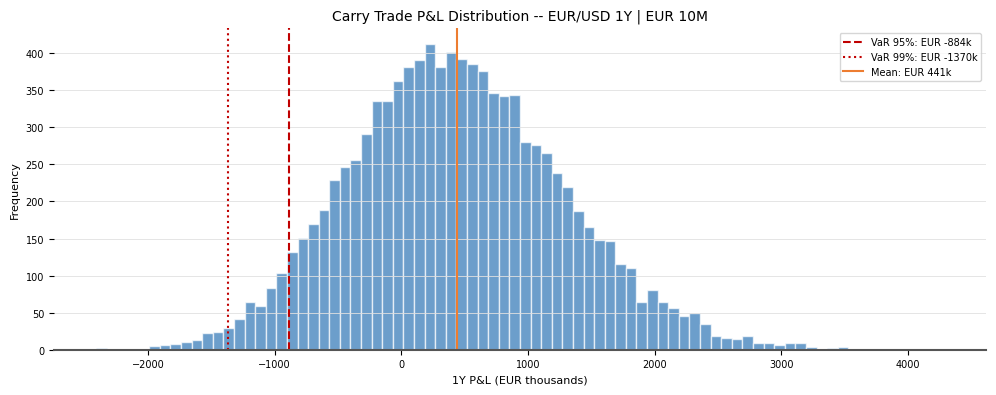

In [7]:
# ── carry VaR -- historical simulation approach ───────────────────────────────
# simulate 1Y returns using lognormal spot dynamics
np.random.seed(42)
n_sims     = 10_000
mu         = 0.0    # zero drift (risk-neutral-ish)
sigma      = impl_vol_1y

# lognormal spot at maturity
z          = np.random.standard_normal(n_sims)
spot_sims  = spot_eurusd * np.exp((mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)

# P&L per simulation
pnl_sims   = carry_eur + notional_eur * (fwd_1y - spot_sims) / spot_sims

var_95  = np.percentile(pnl_sims, 5)
var_99  = np.percentile(pnl_sims, 1)
es_975  = np.mean(pnl_sims[pnl_sims <= np.percentile(pnl_sims, 2.5)])
mean_pnl = np.mean(pnl_sims)

print(f"Carry Trade Risk -- Monte Carlo ({n_sims:,} simulations)")
print(f"Vol assumption: {sigma*100:.1f}% | Carry: {annual_carry_pct:.2f}%")
print(f"\nMean P&L:        EUR {mean_pnl:>10,.0f}")
print(f"VaR 95%:         EUR {var_95:>10,.0f}")
print(f"VaR 99%:         EUR {var_99:>10,.0f}")
print(f"ES 97.5%:        EUR {es_975:>10,.0f}")
print(f"Prob of loss:    {(pnl_sims < 0).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pnl_sims / 1e3, bins=80, color=C1, edgecolor='white', alpha=0.7)
ax.axvline(var_95 / 1e3,  color=C4, linestyle='--', linewidth=1.5, label=f'VaR 95%: EUR {var_95/1e3:.0f}k')
ax.axvline(var_99 / 1e3,  color=C4, linestyle=':',  linewidth=1.5, label=f'VaR 99%: EUR {var_99/1e3:.0f}k')
ax.axvline(mean_pnl / 1e3, color=C2, linestyle='-',  linewidth=1.5, label=f'Mean: EUR {mean_pnl/1e3:.0f}k')
ax.set_xlabel('1Y P&L (EUR thousands)')
ax.set_ylabel('Frequency')
ax.set_title('Carry Trade P&L Distribution -- EUR/USD 1Y | EUR 10M')
ax.legend()
ax.spines['bottom'].set_color('#555555')
plt.tight_layout()
plt.show()

## 6. Multi-Currency Carry Portfolio

Professional carry traders diversify across multiple currency pairs to reduce
idiosyncratic risk. The portfolio approach also allows hedging of correlated
carry unwinds -- which tend to happen simultaneously in risk-off events.

A typical carry portfolio: long high-yielders (USD, BRL, MXN), short
low-yielders (EUR, JPY, CHF).

Multi-Currency Carry Portfolio:
   pair  carry_pct  impl_vol  carry_to_risk position
USD/JPY   3.710000  9.500000       0.390526 long USD
USD/CHF   2.560000  8.000000       0.320000 long USD
EUR/USD   1.810000  8.200000       0.220732 long USD
AUD/JPY   4.000000 12.500000       0.320000 long AUD
NZD/JPY   3.400000 13.000000       0.261538 long NZD
MXN/JPY   9.400000 18.000000       0.522222 long MXN


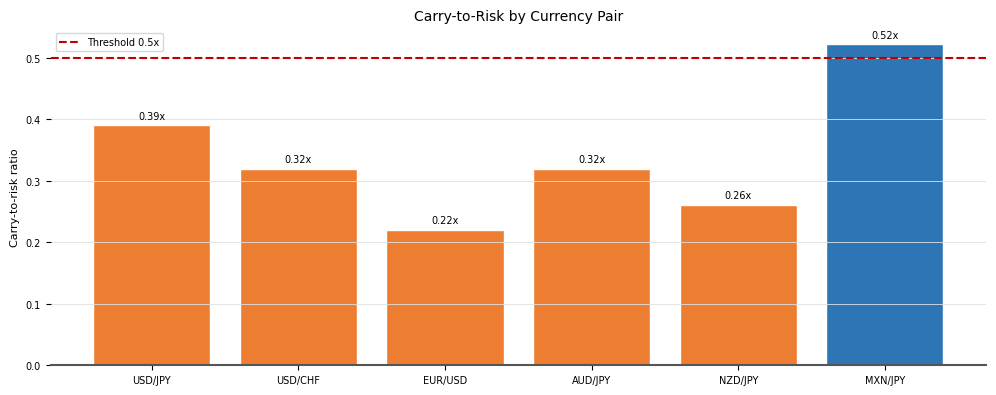

In [8]:
# ── multi-currency carry portfolio ───────────────────────────────────────────
# simplified -- using current approximate rate levels
carry_pairs = pd.DataFrame([
    {'pair': 'USD/JPY',  'funding_rate': 0.10,  'target_rate': 3.81,  'impl_vol': 9.5,  'position': 'long USD'},
    {'pair': 'USD/CHF',  'funding_rate': 1.25,  'target_rate': 3.81,  'impl_vol': 8.0,  'position': 'long USD'},
    {'pair': 'EUR/USD',  'funding_rate': 2.00,  'target_rate': 3.81,  'impl_vol': 8.2,  'position': 'long USD'},
    {'pair': 'AUD/JPY',  'funding_rate': 0.10,  'target_rate': 4.10,  'impl_vol': 12.5, 'position': 'long AUD'},
    {'pair': 'NZD/JPY',  'funding_rate': 0.10,  'target_rate': 3.50,  'impl_vol': 13.0, 'position': 'long NZD'},
    {'pair': 'MXN/JPY',  'funding_rate': 0.10,  'target_rate': 9.50,  'impl_vol': 18.0, 'position': 'long MXN'},
])

carry_pairs['carry_pct']      = carry_pairs['target_rate'] - carry_pairs['funding_rate']
carry_pairs['carry_to_risk']  = carry_pairs['carry_pct'] / carry_pairs['impl_vol']

print("Multi-Currency Carry Portfolio:")
print(carry_pairs[['pair','carry_pct','impl_vol','carry_to_risk','position']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
colors  = [C1 if c > 0.5 else C2 for c in carry_pairs['carry_to_risk']]
bars    = ax.bar(carry_pairs['pair'], carry_pairs['carry_to_risk'], color=colors, edgecolor='white')
ax.axhline(0.5, color=C4, linestyle='--', linewidth=1.5, label='Threshold 0.5x')
ax.set_ylabel('Carry-to-risk ratio')
ax.set_title('Carry-to-Risk by Currency Pair')
ax.legend()
ax.spines['bottom'].set_color('#555555')
for bar, val in zip(bars, carry_pairs['carry_to_risk']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}x', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

## 7. FRTB Risk Classification

Under CRR3 / FRTB SA, carry trade positions generate two risk sensitivities:

**Delta FX (FX risk class):**
- Sensitivity of NPV to a 1% move in the spot rate
- $\Delta_{FX} = -N_f \times (F_0/S_0) \times P_{EUR}(0,T)$
- FRTB FX risk weight: 15% for EUR/USD

**Delta IR (GIRR):**
- Sensitivity to 1bp move in each currency's OIS curve
- $\Delta_{IR} = -N_f \times F_0 \times T \times P_{EUR}(0,T) \times 0.0001$
- FRTB GIRR risk weight varies by tenor

The carry trade has natural long/short positions in both risk factors.

In [9]:
# ── FRTB sensitivity calculation ──────────────────────────────────────────────
dt_1y  = valuation_date + ql.Period(365, ql.Days)
df_e   = eur_zc.discount(dt_1y)
df_u   = usd_zc.discount(dt_1y)
fwd    = spot_eurusd * df_e / df_u
N_f    = notional_eur / spot_eurusd   # USD notional

# delta FX -- 1% spot move
delta_fx = -N_f * (fwd / spot_eurusd) * df_e * 0.01

# delta IR EUR -- 1bp EUR rate move
delta_ir_eur = N_f * fwd * T * df_e * 0.0001

# delta IR USD -- 1bp USD rate move
delta_ir_usd = -N_f * fwd * T * df_e * 0.0001

# FRTB risk weights
rw_fx   = 0.15    # EUR/USD FX risk weight
rw_girr = 0.016   # 1Y GIRR risk weight EUR

ws_fx      = delta_fx * rw_fx / 0.01
ws_ir_eur  = delta_ir_eur * rw_girr / 0.0001
ws_ir_usd  = delta_ir_usd * rw_girr / 0.0001

print(f"FRTB SA Sensitivities -- EUR/USD 1Y Carry Trade")
print(f"Notional: EUR {notional_eur/1e6:.0f}M (USD {N_f/1e6:.2f}M)")
print(f"\n{'Sensitivity':<25} {'Value':>15} {'Risk weight':>12} {'Weighted sens':>15}")
print("-" * 70)
print(f"{'Delta FX (1% spot)':<25} {delta_fx:>15,.2f} {rw_fx*100:>10.0f}% {ws_fx:>15,.2f}")
print(f"{'Delta IR EUR (1bp)':<25} {delta_ir_eur:>15,.2f} {rw_girr*100:>10.1f}% {ws_ir_eur:>15,.2f}")
print(f"{'Delta IR USD (1bp)':<25} {delta_ir_usd:>15,.2f} {rw_girr*100:>10.1f}% {ws_ir_usd:>15,.2f}")
print(f"\nFRTB capital (simplified, no correlation netting):")
print(f"  FX delta capital:  EUR {abs(ws_fx):,.0f}")
print(f"  GIRR delta capital: EUR {abs(ws_ir_eur) + abs(ws_ir_usd):,.0f}")

FRTB SA Sensitivities -- EUR/USD 1Y Carry Trade
Notional: EUR 10M (USD 8.64M)

Sensitivity                         Value  Risk weight   Weighted sens
----------------------------------------------------------------------
Delta FX (1% spot)             -86,199.87         15%   -1,292,998.02
Delta IR EUR (1bp)                 998.02        1.6%      159,683.53
Delta IR USD (1bp)                -998.02        1.6%     -159,683.53

FRTB capital (simplified, no correlation netting):
  FX delta capital:  EUR 1,292,998
  GIRR delta capital: EUR 319,367


## Summary

<small> 

| Concept | Key result | Reference |
|---------|-----------|----------|
| Carry mechanics | Borrow low rate, invest high rate -- pocket differential | CIP / UIP |
| EUR/USD carry | ~180bps annual carry (USD-EUR differential 1Y) | ECB OIS / FRED Treasury |
| Carry-to-risk | Carry % / implied vol -- measure of risk-adjusted attractiveness | Market convention |
| Break-even vol | Carry % -- vol level that wipes out carry | Analytical |
| Unwind risk | Sudden EUR appreciation -- self-reinforcing margin calls | Historical pattern |
| FRTB Delta FX | 15% risk weight on EUR/USD | CRR3 Article 325 |
| FRTB GIRR | 1.6% risk weight at 1Y tenor | CRR3 Article 325 |

</small> 

---
*Notebook QRE-32 | Sprint 5 | Quant Risk Engine*  
*Regulation: CRR3 (EU 2024/1623) FRTB SA, EMIR (EU 648/2012)*